In [1]:
### 1. DATA LOADING AND EXPLORATION
# Load chess openings dataset (originally from Kaggle)
import kagglehub

# Dataset public download link: https://www.kaggle.com/datasets/alexandrelemercier/all-chess-openings?select=openings.csv
# Note: downloaded locally for direct manipulation, but can be used online too
path = kagglehub.dataset_download("alexandrelemercier/all-chess-openings") # Dataset Path


In [3]:
# Install required package
%pip uninstall mlxtend numpy -y
%pip install mlxtend numpy
%pip uninstall numpy -y
%pip install "numpy<2.0" --force-reinstall

# Import necessary libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Set visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

Usage: java [-options] class [args...]
           (to execute a class)
   or  java [-options] -jar jarfile [args...]
           (to execute a jar file)
where options include:
    -d32	  use a 32-bit data model if available
    -d64	  use a 64-bit data model if available
    -server	  to select the "server" VM
                  The default VM is server,
                  because you are running on a server-class machine.


    -cp <class search path of directories and zip/jar files>
    -classpath <class search path of directories and zip/jar files>
                  A : separated list of directories, JAR archives,
                  and ZIP archives to search for class files.
    -D<name>=<value>
                  set a system property
    -verbose:[class|gc|jni]
                  enable verbose output
    -version      print product version and exit
    -version:<value>
                  in a future release.
                  require the specified version to run
    -showversion  print

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
# Load the dataset (assuming it's placed in /content/sample_data/ for Colab)
df = pd.read_csv('sample_data/openings.csv')

# Display the first 20 rows of the dataset
df.head(20)

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
2,2,"Alekhine Defense, Exchange Variation",white,6485,B03,2018-07-06,2244,2194,40.8,27.7,...,Nd5,d4,d6,c4,Nb6,40.8,31.5,1.295238,2645.880,2042.775
3,3,"Alekhine Defense, Four Pawns Attack",white,881,B03,2018-06-20,2187,2130,39.7,23.2,...,Nd5,d4,d6,c4,Nb6,39.7,37.1,1.070081,349.757,326.851
4,4,"Alekhine Defense, Four Pawns Attack, Fianchett...",black,259,B03,2018-05-20,2122,2178,37.8,21.2,...,Nd5,d4,d6,c4,Nb6,40.9,37.8,1.082011,105.931,97.902
5,5,"Alekhine Defense, Four Pawns Attack, Main Line",white,1207,B03,2018-07-01,2243,2190,41.0,25.9,...,Nd5,d4,d6,c4,Nb6,41.0,33.1,1.238671,494.870,399.517
6,6,"Alekhine Defense, Four Pawns Attack, Trifunovi...",black,323,B03,2018-05-10,2231,2277,35.9,24.8,...,Nd5,d4,d6,c4,Nb6,39.3,35.9,1.094708,126.939,115.957
7,7,"Alekhine Defense, General",black,524,B02,2018-06-29,2032,2077,42.2,25.0,...,NaN,NaN,NaN,NaN,NaN,32.8,42.2,0.777251,171.872,221.128
8,8,"Alekhine Defense, Hunt Variation, Lasker Simul...",white,334,B02,2018-06-27,2205,2178,34.1,23.6,...,Nd5,c4,Nb6,c5,Nd5,34.1,42.2,0.808057,113.894,140.948
9,9,"Alekhine Defense, Maroczy Variation",white,931,B02,2018-07-09,2174,2174,36.6,25.7,...,NaN,NaN,NaN,NaN,NaN,36.6,37.7,0.970822,340.746,350.987


In [5]:
# Dataset shape (rows, columns)
df.shape

(1884, 26)

In [6]:
# Basic DataFrame information
df_info = pd.DataFrame(df.dtypes, columns=['Dtype'])
df_info['Unique'] = df.nunique().values
df_info['Null'] = df.isnull().sum().values
df_info

,Dtype,Unique,Null
Unnamed: 0,int64,1884,0
Opening,str,1755,0
Colour,str,2,0
Num Games,int64,1337,0
ECO,str,493,0
Last Played,str,195,0
Perf Rating,int64,536,0
Avg Player,int64,509,0
Player Win %,float64,404,0
Draw %,float64,361,0


**Main dataset columns explanation**

- Opening: name of the opening (e.g. Alekhine Defence)
- Colour: most favorable color (White or Black)
- Num Games: total games played with this opening
- ECO: standard Encyclopedia of Chess Openings code
- Last Played: date of the most recent game
- Perf Rating: average performance rating
- Player Win %, Opponent Win %, Draw %: outcome percentages
- Moves: full move sequence in algebraic notation
- Variation: opening variation/sub-variation
- White_win%, Black_win%, Draw%: result rates by color


In [7]:
### 2. DATA PREPARATION
# Check for duplicated rows
duplicates = df[df.duplicated(keep=False)]
# No duplicates found

In [8]:
# Rows with any missing values
df[df.isnull().any(axis=1)]

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
7,7,"Alekhine Defense, General",black,524,B02,2018-06-29,2032,2077,42.2,25.0,...,NaN,NaN,NaN,NaN,NaN,32.8,42.2,0.777251,171.872,221.128
9,9,"Alekhine Defense, Maroczy Variation",white,931,B02,2018-07-09,2174,2174,36.6,25.7,...,NaN,NaN,NaN,NaN,NaN,36.6,37.7,0.970822,340.746,350.987
10,10,"Alekhine Defense, Modern Variation",white,501,B04,2018-06-25,2397,2336,43.5,31.7,...,Nd5,d4,d6,Nf3,NaN,43.5,24.8,1.754032,217.935,124.248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,1878,"Zukertort Opening, Santasiere's Folly",white,262,A06,2018-06-17,2125,2155,32.8,29.4,...,NaN,NaN,NaN,NaN,NaN,32.8,37.8,0.867725,85.936,99.036
1879,1879,"Zukertort Opening, Sicilian Invitation",black,20045,A04,2018-07-09,2274,2293,31.4,33.9,...,NaN,NaN,NaN,NaN,NaN,34.7,31.4,1.105096,6955.615,6294.130
1880,1880,"Zukertort Opening, Slav Invitation",black,463,A04,2018-07-05,2031,2025,27.0,26.1,...,NaN,NaN,NaN,NaN,NaN,46.9,27.0,1.737037,217.147,125.010
1881,1881,"Zukertort Opening, Symmetrical Variation",black,15625,A04,2018-07-09,2235,2257,28.4,34.4,...,NaN,NaN,NaN,NaN,NaN,37.1,28.4,1.306338,5796.875,4437.500


In [9]:
# Count nulls per row
null_counts = df.isnull().sum(axis=1)

# Rename 'Unnamed: 0' to 'Id'
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)

df_nulls = pd.DataFrame({
    'Id': df['Id'],
    'Null_Count': null_counts
})

# Show only rows with more than 1 null
df_nulls = df_nulls[df_nulls['Null_Count'] > 1]
df_nulls

,Id,Null_Count
1,1,4
7,7,6
9,9,5
20,20,4
21,21,2
...,...,...
1878,1878,5
1879,1879,6
1880,1880,6
1881,1881,6


In [10]:
# Top 10 most frequent ECO codes (important for later modeling)
print(df['ECO'].value_counts().head(10))

ECO
A00    34
B00    22
B06    22
B01    22
C41    21
C42    21
C00    19
B07    18
C44    18
C45    17
Name: count, dtype: int64


In [11]:
# Split move sequence into separate columns
df['moves_split'] = df['Moves'].str.split()

# Extract first 3 moves (key for pattern analysis)
df['move1'] = df['moves_split'].str[0]
df['move2'] = df['moves_split'].str[1]
df['move3'] = df['moves_split'].str[2]

# Preview
print(df[['ECO', 'Opening', 'move1', 'move2', 'move3']].head(40))

    ECO                                            Opening move1 move2  move3
0   B03                 Alekhine Defense, Balogh Variation  1.e4   Nf6   2.e5
1   B02               Alekhine Defense, Brooklyn Variation  1.e4   Nf6   2.e5
2   B03               Alekhine Defense, Exchange Variation  1.e4   Nf6   2.e5
3   B03                Alekhine Defense, Four Pawns Attack  1.e4   Nf6   2.e5
4   B03  Alekhine Defense, Four Pawns Attack, Fianchett...  1.e4   Nf6   2.e5
5   B03     Alekhine Defense, Four Pawns Attack, Main Line  1.e4   Nf6   2.e5
6   B03  Alekhine Defense, Four Pawns Attack, Trifunovi...  1.e4   Nf6   2.e5
7   B02                          Alekhine Defense, General  1.e4   Nf6    NaN
8   B02  Alekhine Defense, Hunt Variation, Lasker Simul...  1.e4   Nf6   2.e5
9   B02                Alekhine Defense, Maroczy Variation  1.e4   Nf6   2.d3
10  B04                 Alekhine Defense, Modern Variation  1.e4   Nf6   2.e5
11  B04  Alekhine Defense, Modern Variation, Alburt Var...  1.e4

**Feature selection**

Although the dataset has 26 columns, we keep only those relevant for opening analysis and outcome clustering:
- ECO
- Moves (to extract initial patterns)
- Player Win %, Opponent Win %, Draw %
- White_win%, Black_win%, Draw%
Other columns are discarded as they don't directly contribute to clustering or association goals.

In [12]:
print("\nSelected features for analysis:")
print(["ECO", "Moves", "Player Win %", "Opponent Win %", "Draw %"])


Selected features for analysis:
['ECO', 'Moves', 'Player Win %', 'Opponent Win %', 'Draw %']


In [13]:
### 3. ASSOCIATION RULES BETWEEN OPENING MOVES
"""
Goal: discover frequent patterns among the first moves of openings
to identify common initial combinations.

Interpretation example:
'move1_e4 → move2_Nf6' means that when white plays e4,
black frequently answers Nf6 (typical of Alekhine Defense).
This shows co-occurrence, not necessarily causality.
"""

# Select first 3 moves and fill NaN with empty string
moves_df = df[['move1', 'move2', 'move3']].fillna("")

# One-hot encode
encoded = pd.get_dummies(moves_df)

# Find frequent itemsets (min support 5%)
frequent_itemsets = apriori(encoded, min_support=0.05, use_colnames=True)

# Generate association rules (min confidence 70%)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Show top rules
print(rules.head(10))

                antecedents              consequents  antecedent support  \
0    frozenset({move2_Nf6})  frozenset({move1_1.d4})            0.242038   
1     frozenset({move2_d5})  frozenset({move1_1.d4})            0.176221   
2   frozenset({move1_1.d4})  frozenset({move3_2.c4})            0.389597   
3   frozenset({move3_2.c4})  frozenset({move1_1.d4})            0.339703   
4     frozenset({move2_c5})  frozenset({move1_1.e4})            0.159766   
5     frozenset({move2_e5})  frozenset({move1_1.e4})            0.226115   
6     frozenset({move2_e6})  frozenset({move1_1.e4})            0.072718   
7  frozenset({move3_2.Nf3})  frozenset({move1_1.e4})            0.319002   
8   frozenset({move3_2.d4})  frozenset({move1_1.e4})            0.126858   
9    frozenset({move2_Nf6})  frozenset({move3_2.c4})            0.242038   

   consequent support   support  confidence      lift  representativity  \
0            0.389597  0.205414    0.848684  2.178367               1.0   
1            

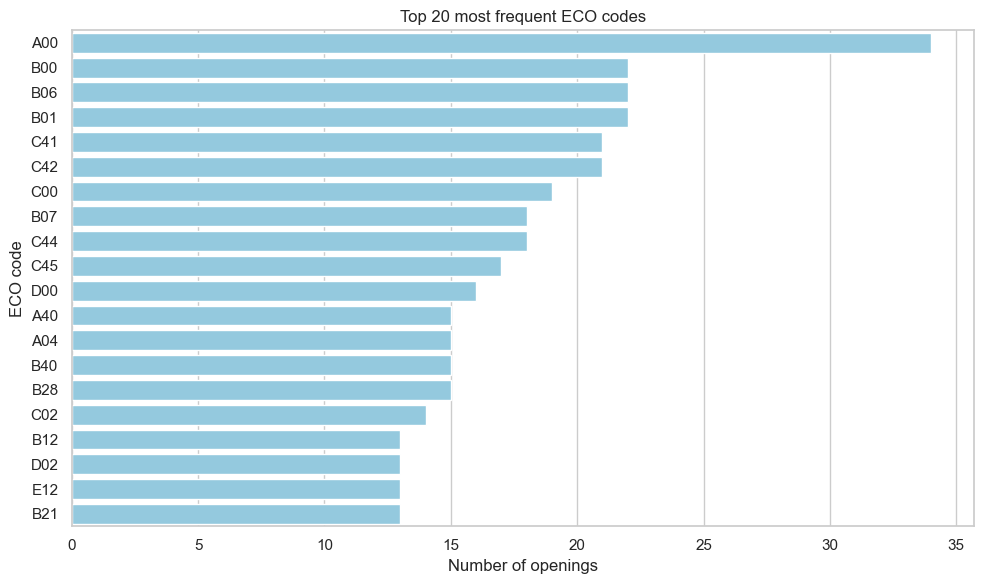

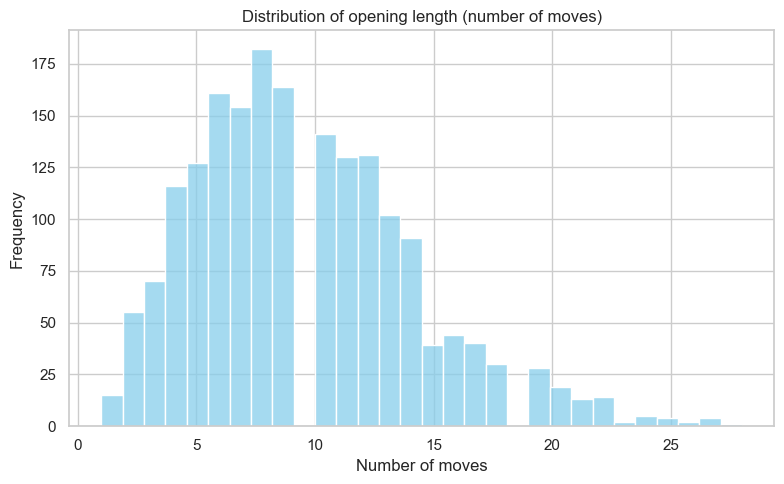

In [14]:
### 4. VISUALIZATIONS FOR ASSOCIATION RULES & FREQUENCY
# Top 20 most frequent ECO codes
eco_counts = df['ECO'].value_counts().nlargest(20)
plt.figure(figsize=(10,6))
sns.barplot(x=eco_counts.values, y=eco_counts.index, color="skyblue")
plt.title("Top 20 most frequent ECO codes")
plt.xlabel("Number of openings")
plt.ylabel("ECO code")
plt.tight_layout()
plt.show()

"""
Note: longer openings tend to produce more detectable repetitive patterns,
which aligns with the association rules analysis.
"""

# Length of move sequences
df['length'] = df['moves_split'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['length'], bins=30, color="skyblue")
plt.title("Distribution of opening length (number of moves)")
plt.xlabel("Number of moves")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

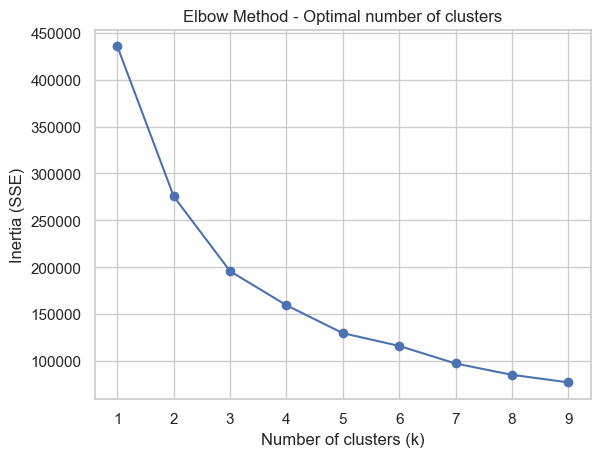


Cluster summary:
          Player Win %  Opponent Win %     Draw %
cluster                                         
0           43.467959       28.935142  27.597674
1           28.475153       32.247862  39.278615
2           30.072375       44.549596  25.382391


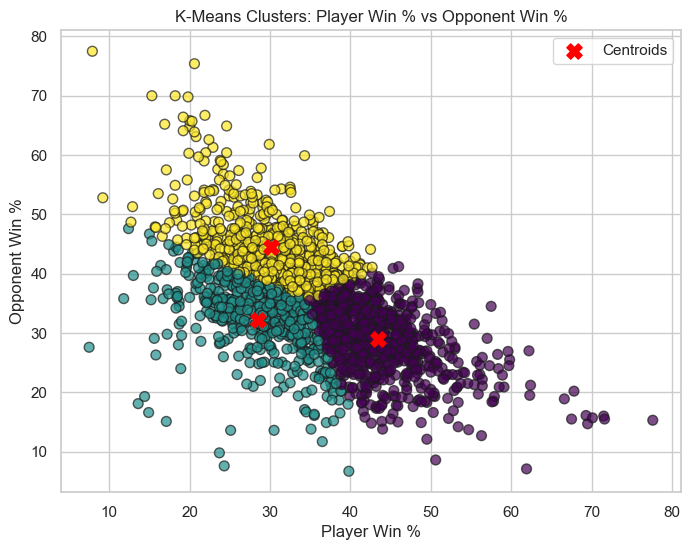

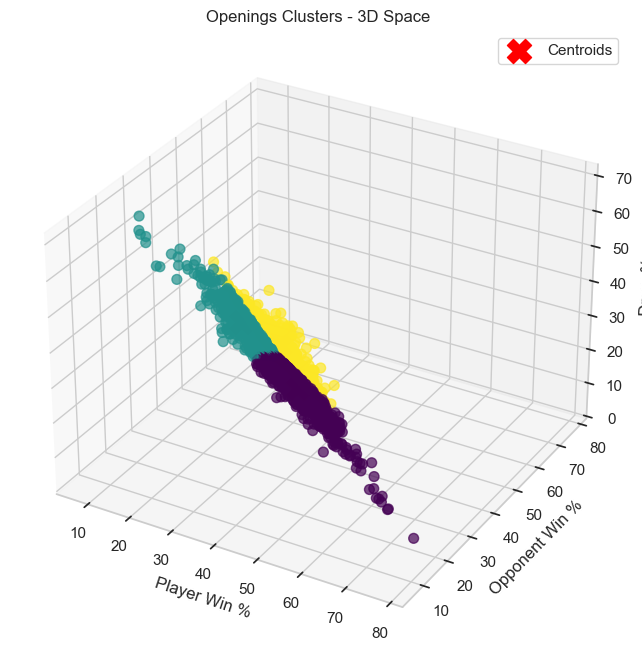

In [15]:
### 5. CLUSTERING OF OPENINGS
"""
Goal: group openings based on statistical outcomes
to identify families with similar tendencies
(e.g. white-favoring, black-favoring, drawish, balanced).

Example cluster interpretation:
- Cluster 0: high white wins → aggressive first-player openings
- Cluster 1: balanced wins/draws → solid/symmetrical openings
- Cluster 2: high opponent wins → effective black defenses
"""

# Select features
X = df[["Player Win %", "Opponent Win %", "Draw %"]].dropna()

# Elbow method to find optimal k
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method - Optimal number of clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.show()

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Cluster summary
cluster_summary = df.groupby("cluster")[["Player Win %", "Opponent Win %", "Draw %"]].mean()
print("\nCluster summary:\n", cluster_summary)

# 2D visualization
plt.figure(figsize=(8,6))
plt.scatter(X["Player Win %"], X["Opponent Win %"], c=df["cluster"], cmap="viridis", s=50, alpha=0.7, edgecolor="k")
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=120, marker="X", label="Centroids")
plt.title("K-Means Clusters: Player Win % vs Opponent Win %")
plt.xlabel("Player Win %")
plt.ylabel("Opponent Win %")
plt.legend()
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X["Player Win %"], X["Opponent Win %"], X["Draw %"], c=df["cluster"], cmap="viridis", s=50, alpha=0.7)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c="red", s=300, marker="X", label="Centroids")
ax.set_xlabel("Player Win %")
ax.set_ylabel("Opponent Win %")
ax.set_zlabel("Draw %")
ax.set_title("Openings Clusters - 3D Space")
ax.legend()
plt.show()

**General Conclusion**

Descriptive data mining techniques (K-Means + association rules)
successfully revealed strategic patterns in chess openings.
The resulting clusters group similar behavioral families,
making it easier to study and understand opening theory.